## Ulkeleri askeri guclerine gore gruplara ayirma

1. trillion dolar : bu sadece america icine girer.
2. rusya ve cin bunlar kendi teknolojilerini uretiyorlar ama amerika kadar guclu degiller
3. Turkiye, Brazilya, Almanya, Fransa bunlar teknolojilerinin cogunu disaridan aliyorlar. Ama kendileri de cok az bir sey yapiyorlar.
4. Hic savunma sanayilari yok. or Afganistan denize kiyilari olmadigi icin deniz donanmalari yok.

* Nasıl yapılacak?

1. header=[0, 1] eşitleyerek pandasın atayacağı unnamed sütünlerden arınacağız.
2. alt sütünlerdeki sayısal veriler olan sütünlere ulaşılıp o sütünü scale etmeden önce boş dönen varsa o sütünün medianıyla dolduruyoruz.
3. scale ettikten sonra alt sütünlerinin ortalamalarını ana sütünlere dahil ediyoruz.
4. ana sütünleri scale ediyoruz.
5. bunları yeni bir data frame'in içine atıyoruz.
6. kmeans'e 4 küme oluşturacak şekilde model oluşturuyoruz.

In [1]:
#pip install seaborn

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_excel("World military power.xlsx", header=[0, 1])

In [4]:
df.head()

2020 ranking                               Airforce Strength  \
  Military Strength Military Strength Power Index Aircraft Strength   
0       Afghanistan                        1.3444       Afghanistan   
1           Albania                        2.3137           Albania   
2           Algeria                        0.4659           Algeria   
3            Angola                        0.8379            Angola   
4         Argentina                        0.6521         Argentina   

                                                        \
  Aircraft Strength value Fighter/Interceptor Strength   
0                     260                  Afghanistan   
1                      19                      Albania   
2                     551                      Algeria   
3                     295                       Angola   
4                     227                    Argentina   

                                                               \
  Fighter/Interceptor Strength value Attack Aircraft Strength   
0                                  0              Afghanistan   
1                                  0                  Albania   
2                                103                  Algeria   
3                                 72                   Angola   
4                                 24                Argentina   

                                                                    \
  Attack Aircraft Strength value Transport Aircraft Fleet Strength   
0                             25                       Afghanistan   
1                              0                           Albania   
2                             22                           Algeria   
3                             18                            Angola   
4                              7                         Argentina   

                                           ...         Manpower  \
  Transport Aircraft Fleet Strength value  ... Total Population   
0                                      30  ...      Afghanistan   
1                                       0  ...          Albania   
2                                      59  ...          Algeria   
3                                      30  ...           Angola   
4                                       9  ...        Argentina   

                                      Geography                               \
  Total Population value Total Square Land Area Total Square Land Area value   
0            3,49,40,837            Afghanistan                     6,52,230   
1              30,57,220                Albania                        28748   
2            4,16,57,488                Algeria                    23,81,741   
3            3,03,55,880                 Angola                    12,46,700   
4            4,46,94,198              Argentina                    27,80,400   

                                                           \
  Total Coastline Coverage Total Coastline Coverage value   
0              Afghanistan                              0   
1                  Albania                            362   
2                  Algeria                            998   
3                   Angola                           1600   
4                Argentina                           4989   

                                                                               \
  Total Waterway Coverage Total Waterway Coverage value Total Border Coverage   
0             Afghanistan                          1200           Afghanistan   
1                 Albania                            41               Albania   
2                 Algeria                             0               Algeria   
3                  Angola                          1300                Angola   
4               Argentina                         11000             Argentina   

                               
  Total Border Coverage value  
0                      5987.0  
1                       691.0  


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 138 entries, 0 to 137
Data columns (total 60 columns):
 #   Column                                                        Non-Null Count  Dtype  
---  ------                                                        --------------  -----  
 0   (2020 ranking, Military Strength)                             138 non-null    str    
 1   (2020 ranking, Military Strength Power Index)                 138 non-null    float64
 2   (Airforce Strength, Aircraft Strength)                        138 non-null    str    
 3   (Airforce Strength, Aircraft Strength value)                  138 non-null    int64  
 4   (Airforce Strength, Fighter/Interceptor Strength)             138 non-null    str    
 5   (Airforce Strength, Fighter/Interceptor Strength value)       138 non-null    int64  
 6   (Airforce Strength, Attack Aircraft Strength)                 138 non-null    str    
 7   (Airforce Strength, Attack Aircraft Strength value)           138 non-null    int6

* Pandas ana header yanındaki satırlar boş olduğundan unnamed diye isim takar. ilk önce bunu sileceğiz yani, sütünün tamamını silmeyeceğiz tamir edeceğiz ta ki herbir alt sütünleri scale edip ve bütün alt sütünlerin ortalamasını alıp ana sütünlere entegre edebilelim.
* ondan sonra bütün alt sütünlardaki değer döndüren verilere ulaşıp eğer boş dönen veriler varsa onları mediian ile doldurup sütünü scale edeceğiz.
* scale ettiğimiz o alt sütünlerin ortalamasını baş sütünlere entegre edeceğiz.
* ana sütünleri de scale edip elbow değere göre clustering yapacağız.

In [6]:
df.columns

MultiIndex([(     '2020 ranking',                       'Military Strength'),
            (     '2020 ranking',           'Military Strength Power Index'),
            ('Airforce Strength',                       'Aircraft Strength'),
            ('Airforce Strength',                 'Aircraft Strength value'),
            ('Airforce Strength',            'Fighter/Interceptor Strength'),
            ('Airforce Strength',      'Fighter/Interceptor Strength value'),
            ('Airforce Strength',                'Attack Aircraft Strength'),
            ('Airforce Strength',          'Attack Aircraft Strength value'),
            ('Airforce Strength',       'Transport Aircraft Fleet Strength'),
            ('Airforce Strength', 'Transport Aircraft Fleet Strength value'),
            ('Airforce Strength',                  'Trainer Aircraft Fleet'),
            ('Airforce Strength',            'Trainer Aircraft Fleet value'),
            ('Airforce Strength',               'Helicopter Flee

* Country ve Power Index sütunlarını bozmamak için onları bir kenara ayıracağız.

* Geriye kalan askeri/ekonomik ana başlıkların (Airforce Strength, Land Strength vb.) listesini çıkaracağız.

In [7]:
ana_basliklar = list(dict.fromkeys([col[0] for col in df.columns if "ranking" not in col[0].lower()]))
print(ana_basliklar)

['Airforce Strength', 'Land Strength', 'Navy Strength', 'Finances', 'Logistics', 'Natural resources', 'Manpower', 'Geography']


In [8]:
for baslik in ana_basliklar:
    alt_basliklar = [col[1] for col in df.columns if col[0] == baslik and "ranking" not in col[0].lower()]
    print(f"{baslik}: {alt_basliklar}")

Airforce Strength: ['Aircraft Strength', 'Aircraft Strength value', 'Fighter/Interceptor Strength', 'Fighter/Interceptor Strength value', 'Attack Aircraft Strength', 'Attack Aircraft Strength value', 'Transport Aircraft Fleet Strength', 'Transport Aircraft Fleet Strength value', 'Trainer Aircraft Fleet', 'Trainer Aircraft Fleet value', 'Helicopter Fleet Strength', 'Helicopter Fleet Strength value', 'Attack Helicopter Fleet Strength', 'Attack Helicopter Fleet Strength value']
Land Strength: ['Tank Strength', 'Tank Strength value', 'AFV/APC Strength', 'AFV/APC Strength value', 'Self-Propelled Artillery Strength', 'Self-Propelled Artillery Strength value', 'Towed Artillery Strength', 'Towed Artillery Strength value', 'Rocket Projector Strength', 'Rocket Projector Strength value']
Navy Strength: ['Navy Fleet Strengths', 'Navy Fleet Strengths value', 'Aircraft Carrier Fleet Strength', 'Aircraft Carrier Fleet Strength value', 'Submarine Fleet Strength', 'Submarine Fleet Strength value', 'Des

In [9]:
# --- Ana Başlıkları Filtreleme ---
ana_basliklar = list(dict.fromkeys([col[0] for col in df.columns if "ranking" not in col[0].lower()]))

# --- En Baştaki Referans Değerleri Koruma Yani ülkeyi ve power rankingi---
en_bastan_ulkeler = df.iloc[:, 0]
power_index_serisi = df.iloc[:, 1]

# Power Index temizliği
power_index_serisi = power_index_serisi.astype(str).str.replace(',', '')
power_index_serisi = pd.to_numeric(power_index_serisi, errors='coerce')

# Yeni tablonun temeli (Sıralama verileri korundu)
yeni_veri = {
    'Country': en_bastan_ulkeler,
    'Military Strength Power Index': power_index_serisi
}

# --- Döngü İçinde Temizlik, Ölçekleme ve Ortalama. Burada ilk önce alt sütünlerdeki sayısal veriler olan sütünlere ulaşılıyor. ---
for ana in ana_basliklar:
    alt_grup = df[ana]
    
    # Sayısal alt sütunları cımbızla çekme
    sayisal_alt_sutunlar = [
        col for col in alt_grup.columns 
        if any(anahtar in col.lower() for anahtar in ['value', 'budget', 'total', 'production', 'consumption', 'reserves', 'population', 'coverage'])
    ]
    
    if len(sayisal_alt_sutunlar) == 0:
        continue
        
    # Veri temizleme ve boşlukları medyan ile doldurma
    temiz_alt_grup = alt_grup[sayisal_alt_sutunlar].copy()
    for col in temiz_alt_grup.columns:
        temiz_alt_grup[col] = temiz_alt_grup[col].astype(str).str.replace(',', '')
        temiz_alt_grup[col] = pd.to_numeric(temiz_alt_grup[col], errors='coerce')
        temiz_alt_grup[col] = temiz_alt_grup[col].fillna(temiz_alt_grup[col].median())
    
    # Alt sütunları kendi içinde scale et
    scaler_alt = StandardScaler()
    olcekli_alt_grup = pd.DataFrame(
        scaler_alt.fit_transform(temiz_alt_grup), 
        columns=temiz_alt_grup.columns, 
        index=temiz_alt_grup.index
    )
    
    # Scaled sütunların ortalamasını (mean) al
    tek_sutun_ortalama = olcekli_alt_grup.mean(axis=1)
    
    # Ortalaması alınan nihai sütunu son bir kez daha scale et
    scaler_nihai = StandardScaler()
    nihai_olcekli_sutun = scaler_nihai.fit_transform(tek_sutun_ortalama.values.reshape(-1, 1)).flatten()
    
    # Sözlüğe ana başlık adıyla kaydet
    yeni_veri[ana] = nihai_olcekli_sutun

# DataFrame Dönüşümü ---
final_df = pd.DataFrame(yeni_veri)



/home/zaid/Desktop/Yapay-Zeka-Kursu/venv/lib/python3.14/site-packages/sklearn/utils/extmath.py:1211: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/home/zaid/Desktop/Yapay-Zeka-Kursu/venv/lib/python3.14/site-packages/sklearn/utils/extmath.py:1216: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/home/zaid/Desktop/Yapay-Zeka-Kursu/venv/lib/python3.14/site-packages/sklearn/utils/extmath.py:1240: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count
/home/zaid/Desktop/Yapay-Zeka-Kursu/venv/lib/python3.14/site-packages/sklearn/utils/extmath.py:1211: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/home/zaid/Desktop/Yapay-Zeka-Kursu/venv/lib/python3.14/site-packages/sklearn/utils/extmath.py:1216: RuntimeWarning: invalid value encountered in divide
  T = new_sum / 

In [10]:
final_df.head()

,Country,Military Strength Power Index,Airforce Strength,Land Strength,Navy Strength,Finances,Logistics,Natural resources,Manpower,Geography
0,Afghanistan,1.3444,-0.150608,-0.326811,-0.443378,-0.161792,-0.204411,-0.390521,-0.121546,-0.031768
1,Albania,2.3137,-0.315349,-0.421517,-0.373848,-0.251213,-0.236680,-0.377968,-0.294630,-0.599058
2,Algeria,0.4659,0.135463,0.296032,0.255576,-0.153053,-0.110084,0.108442,-0.062990,0.274568
3,Angola,0.8379,-0.076414,-0.203213,-0.339083,-0.189535,-0.094363,0.113439,-0.183519,0.028668
4,Argentina,0.6521,-0.186578,-0.271830,-0.202134,-0.162357,0.701623,-0.123010,-0.057093,1.068812


In [11]:
#pip install yellowbrick

In [12]:
#pip install setuptools

In [13]:
#from yellowbrick.cluster import KElbowVisualizer bu çalışmadı

In [14]:
from sklearn.cluster import KMeans

x = final_df.drop(columns=['Country'])

In [15]:
#wcss= within cluster sum of squares
from sklearn.metrics import silhouette_score


wcss=[]
ss=[]
for i in range(2,10):
    model=KMeans(i)
    model=model.fit(x)
    tahmin=model.predict(x)
    ss1=silhouette_score(x,tahmin)
    ss.append(ss1)
    print(ss1)
    wcss.append(model.inertia_)

0.8343467358218247
0.3006291234422338
0.35431109199786787
0.3769193470775377
0.3300658231933655
0.33588430093153887
0.31668216863959003
0.3174395312514778


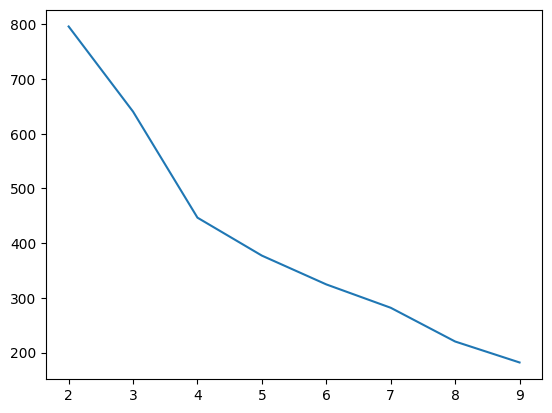

In [16]:
plt.plot(range(2,10),wcss)

In [17]:
model = KMeans(n_clusters=4, random_state=42, n_init=10)
final_df['Cluster'] = model.fit_predict(x)

<Axes: xlabel='Cluster', ylabel='count'>

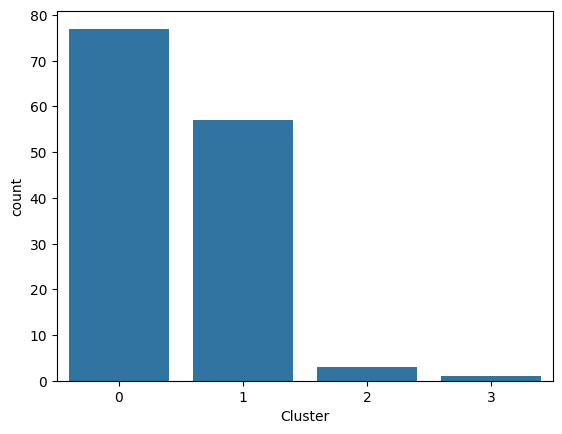

In [19]:
sns.countplot(x = final_df['Cluster'])

In [ ]:
print(f"\nKÜME {0} ")
ulkeler = final_df[final_df['Cluster'] == 0]['Country'].values
print(ulkeler)


KÜME 0 
<StringArray>
[                     'Afghanistan',                          'Algeria',
                           'Angola',                        'Argentina',
                        'Australia',                          'Austria',
                       'Azerbaijan',                       'Bangladesh',
                          'Belarus',                          'Belgium',
                          'Bolivia',                           'Brazil',
                         'Bulgaria',                           'Canada',
                            'Chile',                         'Colombia',
                          'Croatia',                             'Cuba',
                          'Czechia', 'Democratic Republic of the Congo',
                          'Denmark',                          'Ecuador',
                            'Egypt',                         'Ethiopia',
                          'Finland',                           'France',
                          'G

In [ ]:
print(f"\nKÜME {1} ")
ulkeler = final_df[final_df['Cluster'] == 1]['Country'].values
print(ulkeler)


KÜME 1 
<StringArray>
[                 'Albania',                  'Armenia',
                  'Bahrain',                   'Bhutan',
   'Bosnia and Herzegovina',                 'Botswana',
             'Burkina Faso',                 'Cambodia',
                 'Cameroon', 'Central African Republic',
                     'Chad',       'Dominican Republic',
              'El Salvador',                  'Estonia',
                    'Gabon',                  'Georgia',
                    'Ghana',                'Guatemala',
                 'Honduras',                  'Ireland',
              'Ivory Coast',                    'Kenya',
               'Kyrgyzstan',                     'Laos',
                   'Latvia',                  'Lebanon',
                  'Liberia',                'Lithuania',
               'Madagascar',                     'Mali',
               'Mauritania',                  'Moldova',
                 'Mongolia',               'Montenegro',
        

In [ ]:
print(f"\nKÜME {2} ")
ulkeler = final_df[final_df['Cluster'] == 2]['Country'].values
print(ulkeler)


KÜME 2 
<StringArray>
['China', 'India', 'Russia']
Length: 3, dtype: str


In [ ]:
print(f"\nKÜME {3} ")
ulkeler = final_df[final_df['Cluster'] == 3]['Country'].values
print(ulkeler)


KÜME 3 
<StringArray>
['United States']
Length: 1, dtype: str


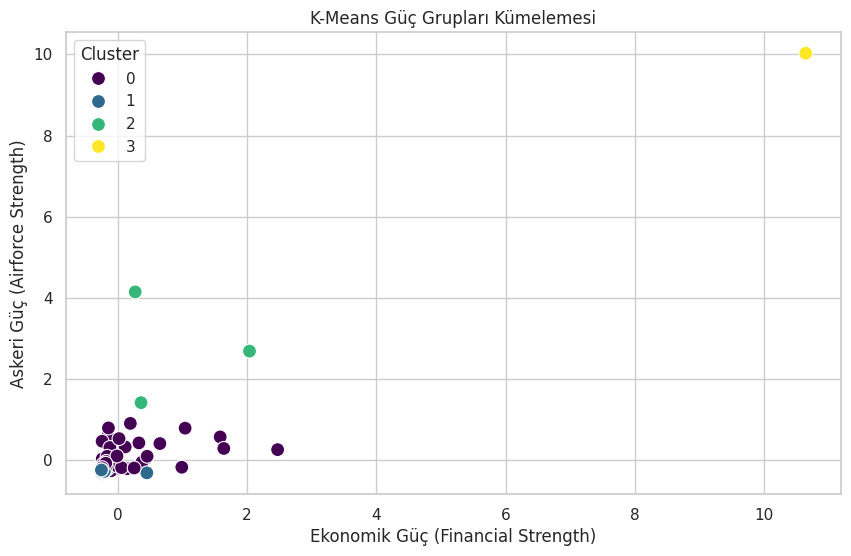

In [ ]:

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=final_df,
    x='Finances',
    y='Airforce Strength',
    hue='Cluster',
    palette='viridis',
    s=100,
    legend='full'
)

plt.title("K-Means Güç Grupları Kümelemesi")
plt.xlabel("Ekonomik Güç (Financial Strength)")
plt.ylabel("Askeri Güç (Airforce Strength)")
plt.show()
